# Segment 1: Introduction

*Contributed by Joyce Jiang*

This notebook uses a pretrained **InceptionV1 (GoogLeNet)** model and a single ImageNet-style image to build intuition for how convolutional neural networks transform raw pixels into progressively more abstract visual representations. This provides foundational understanding of CNN architecture for studying vision model explainability and feature visualization methods such as the OpenAI Microscope.

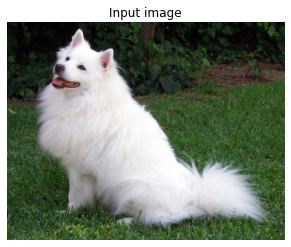

In [36]:
import torch
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request

device = "cuda" if torch.cuda.is_available() else "cpu"

# Download + show example image
def get_example_image():
    url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
    path = "example.jpg"
    urllib.request.urlretrieve(url, path)
    return path

path = get_example_image()
raw = Image.open(path).convert("RGB")

plt.imshow(raw)
plt.axis("off")
plt.title("Input image")
plt.show()

def load_image(path):
    tfm = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406],
                    [0.229, 0.224, 0.225])
    ])
    img = Image.open(path).convert("RGB")
    return tfm(img).unsqueeze(0).to(device)

def load_model():
    model = models.googlenet(pretrained=True, aux_logits=False)
    model.eval().to(device)
    return model

x = load_image(path)
model = load_model()

## 1️⃣ First impressions: from pixels to early visual features

### Conceptual intuition

At the earliest convolutional layer, a CNN does not represent objects or semantic categories.
Instead, it produces a dense grid of local activations corresponding to simple visual primitives.

#### Spatial locality & weight sharing: 

1. Each convolutional filter detects a local pattern (e.g., edges, color contrasts, orientations).

2. Filters are applied identically at every spatial location (weight sharing).

3. As a result, the same visual primitive can be detected anywhere in the image.

This design introduces strong inductive biases that shape early visual representations:

1. **Spatial locality**: responses depend on small, local neighborhoods of pixels.

2. **Translation equivariance**: shifting the image shifts the activations.

3. **Parameter efficiency**: the same filter is reused across the image.

This stage of processing closely resembles early human visual processing (e.g., V1-like responses), where perception is driven by local structure rather than semantic interpretation.

### What to look for visually

All visualizations in this section show **feature maps (activation patterns)** produced by a convolutional layer.

- Strong responses around edges, boundaries, and texture transitions

- Repeated activation patterns across different spatial locations

- No explicit notion of objects or categories—only visual primitives

- Spatial layout of the image largely preserved

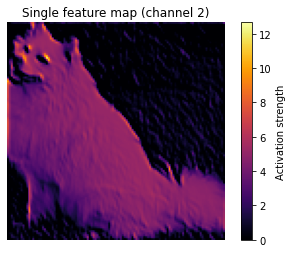

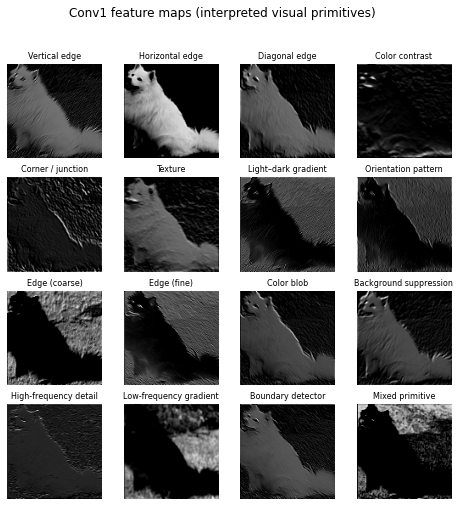

In [37]:
def show_single_feature_map(conv, x, channel=2):
    """
    Visualize a single feature map from a convolutional layer.

    This shows how one learned filter responds across all spatial locations
    in the image (illustrating weight sharing and spatial locality).
    """

    with torch.no_grad():
        feature_map = conv(x)[0, channel].cpu()

    plt.imshow(feature_map, cmap="inferno")
    plt.colorbar(label="Activation strength")
    plt.title(f"Single feature map (channel {channel})")
    plt.axis("off")
    plt.show()

show_single_feature_map(model.conv1, x, channel=2)

def show_feature_maps_with_labels(conv, x, n=16):
    """
    Visualize multiple feature maps from a convolutional layer with
    human-interpreted visual primitive labels.

    Each panel corresponds to one filter's activation pattern.
    Labels are illustrative, not ground truth.
    """

    primitive_labels = [
        "Vertical edge",
        "Horizontal edge",
        "Diagonal edge",
        "Color contrast",
        "Corner / junction",
        "Texture",
        "Light–dark gradient",
        "Orientation pattern",
        "Edge (coarse)",
        "Edge (fine)",
        "Color blob",
        "Background suppression",
        "High-frequency detail",
        "Low-frequency gradient",
        "Boundary detector",
        "Mixed primitive",
    ]

    with torch.no_grad():
        feature_maps = conv(x)[0].cpu()  # [channels, H, W]

    plt.figure(figsize=(8, 8))
    for i in range(n):
        plt.subplot(4, 4, i + 1)
        plt.imshow(feature_maps[i], cmap="gray")
        plt.title(primitive_labels[i], fontsize=8)
        plt.axis("off")

    plt.suptitle("Conv1 feature maps (interpreted visual primitives)", fontsize=12)
    plt.show()

show_feature_maps_with_labels(model.conv1, x)

## 2️⃣ Convolutional filters as local pattern detectors

### Conceptual intuition

Each convolutional filter acts as a reusable local template that scans across the image.
Rather than learning global concepts, CNNs learn a vocabulary of small visual patterns that can be recombined across space.

This is the computational origin of:

- **locality** (small receptive fields)

- **compositionality** (features build on features)

### What to look for visually

- Edge-like and color-selective filters

- Orientation sensitivity (horizontal, vertical, diagonal)

- Filters are not interpretable concepts, but visual building blocks

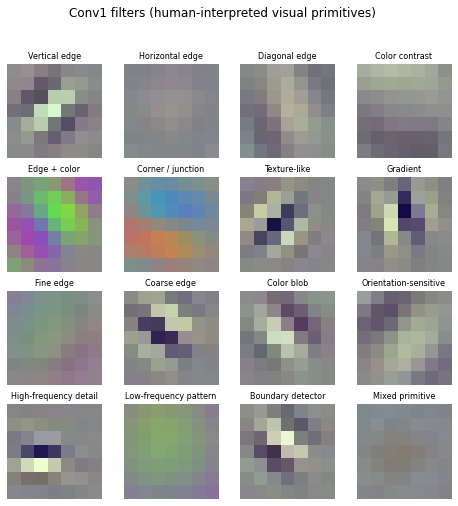

In [27]:
def show_filters_with_labels(layer, n=16):
    """
    Visualize convolutional filters with human-interpreted labels.

    NOTE:
    These labels are approximate, post-hoc interpretations meant
    to build intuition about common early CNN primitives.
    """

    # Unwrap BasicConv2d if needed
    conv = layer.conv if hasattr(layer, "conv") else layer
    W = conv.weight.data.cpu()
    W = (W - W.min()) / (W.max() - W.min())

    # Typical early-layer visual primitives (illustrative, not exact)
    primitive_labels = [
        "Vertical edge",
        "Horizontal edge",
        "Diagonal edge",
        "Color contrast",
        "Edge + color",
        "Corner / junction",
        "Texture-like",
        "Gradient",
        "Fine edge",
        "Coarse edge",
        "Color blob",
        "Orientation-sensitive",
        "High-frequency detail",
        "Low-frequency pattern",
        "Boundary detector",
        "Mixed primitive",
    ]

    plt.figure(figsize=(8, 8))
    for i in range(n):
        plt.subplot(4, 4, i + 1)
        plt.imshow(W[i].permute(1, 2, 0))
        plt.title(primitive_labels[i], fontsize=8)
        plt.axis("off")

    plt.suptitle("Conv1 filters (human-interpreted visual primitives)", fontsize=12)
    plt.show()

show_filters_with_labels(model.conv1)

## 4️⃣ Increasing depth → increasing abstraction

### Conceptual intuition

As depth increases, CNNs progressively:

- lose fine spatial detail

- gain selectivity and invariance

- represent larger, more abstract visual patterns

This hierarchical transformation is the foundation for why feature visualization becomes meaningful in deeper layers.

### What to look for visually

- Early layers: dense, local activations

- Mid layers: repeated motifs and parts

- Late layers: sparse, selective responses

/Users/joycejiang/opt/anaconda3/lib/python3.8/site-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  ../c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)
[W NNPACK.cpp:79] Could not initialize NNPACK! Reason: Unsupported hardware.


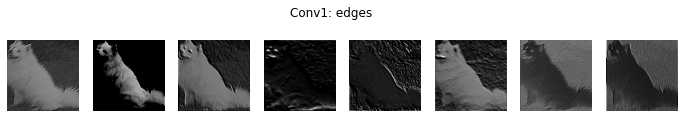

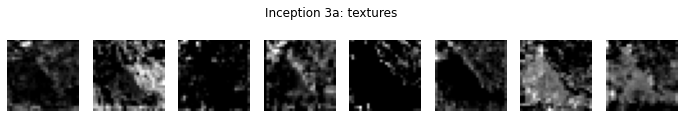

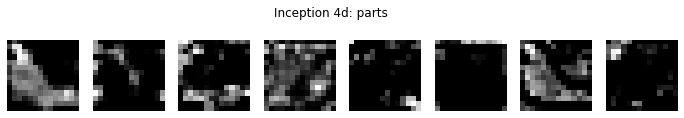

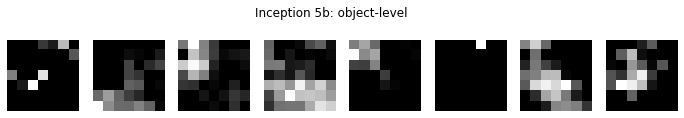

In [16]:
def get_activation(model, layer, x):
    act = {}
    layer.register_forward_hook(lambda m, i, o: act.setdefault("a", o.detach().cpu()))
    with torch.no_grad():
        model(x)
    return act["a"][0]

def show_layer(feats, title, n=8):
    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(feats[i], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

for layer, name in [
    (model.conv1, "Conv1: edges"),
    (model.inception3a, "Inception 3a: textures"),
    (model.inception4d, "Inception 4d: parts"),
    (model.inception5b, "Inception 5b: object-level"),
]:
    feats = get_activation(model, layer, x)
    show_layer(feats, name)